This notebook aims to build a machine learning model to classify SMS messages as 'spam' or 'ham' (not spam). The process involves data loading, cleaning, exploratory data analysis, text preprocessing, feature extraction, model training, and evaluation.

### Imports
Essential libraries are imported for data manipulation, numerical operations, machine learning tasks, natural language processing, and visualization.

In [ ]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import nltk as nk
import re


### Data Loading and Initial Inspection
The dataset, named `spam.csv`, is loaded into a pandas DataFrame. The `encoding='latin-1'` parameter is used to handle potential character encoding issues in the dataset. An initial inspection using `df.sample()` provides a quick view of the data's structure and content.

In [ ]:
df=pd.read_csv('spam.csv',encoding='latin-1')
df.sample

<bound method NDFrame.sample of         v1  \
0      ham   
1      ham   
2     spam   
3      ham   
4      ham   
...    ...   
5567  spam   
5568   ham   
5569   ham   
5570   ham   
5571   ham   

                                                                                                                                                                     v2  \
0                                                       Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...   
1                                                                                                                                         Ok lar... Joking wif u oni...   
2           Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's   
3                                                                                                                  

## 1 Dataset Cleaning

### Column Cleaning and Renaming
The dataset contains three unnamed columns (`Unnamed: 2`, `Unnamed: 3`, `Unnamed: 4`) that are largely empty or contain irrelevant data, as observed during initial data exploration. These columns are dropped to streamline the DataFrame. The primary columns, `v1` and `v2`, are renamed to `target` and `email_text` respectively, for improved clarity and readability within the context of spam classification.

In [ ]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
df.rename(columns={'v1':'target','v2':'email_text'},inplace=True)

### Target Variable Encoding
The `target` column, which indicates whether a message is 'ham' or 'spam', is a categorical variable. To prepare it for machine learning models, which typically require numerical input, `LabelEncoder` from `sklearn.preprocessing` is used to convert 'spam' to 1 and 'ham' to 0. This binary encoding is standard for binary classification problems.

In [ ]:
## labeling the target: Spam=1,ham=0
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

df['target']=encoder.fit_transform(df['target'])

df.sample(10)

,target,email_text
2719,0,Go where n buy? Juz buy when we get there lar.
4379,0,Done it but internet connection v slow and canÛ÷t send it. Will try again later or first thing tomo.
760,1,"Romantic Paris. 2 nights, 2 flights from å£79 Book now 4 next year. Call 08704439680Ts&Cs apply."
5445,0,"And that's fine, I got enough bud to last most of the night at least"
4849,0,Maybe you should find something else to do instead???
5365,1,Camera - You are awarded a SiPix Digital Camera! call 09061221066 fromm landline. Delivery within 28 days.
2703,0,Yup no more already... Thanx 4 printing n handing it up.
4234,1,FREEMSG: Our records indicate you may be entitled to 3750 pounds for the Accident you had. To claim for free reply with YES to this msg. To opt out text STOP
1099,0,Been up to ne thing interesting. Did you have a good birthday? When are u wrking nxt? I started uni today.
4586,0,"I'll see if I can swing by in a bit, got some things to take care of here firsg"


In [ ]:
##check for missing and duplicate values
df.isnull().sum()

target        0
email_text    0
dtype: int64

### Handling Missing and Duplicate Values
Prior to further analysis, it is crucial to ensure data quality by checking for and addressing missing and duplicate entries.

*   `df.isnull().sum()`: This command calculates the number of missing values for each column. The output indicates that there are no missing values in the `target` or `email_text` columns after initial cleaning.
*   `df.duplicated().sum()`: This command identifies the total count of duplicate rows. Duplicates are common in text datasets and can lead to biased model training if not removed.
*   `df=df.drop_duplicates(keep='first')`: Duplicate rows are removed, retaining only the first occurrence of each unique message. This step prevents the model from being overfitted to redundant data.

In [ ]:
##check for duplicated rows
df.duplicated().sum()

df=df.drop_duplicates(keep='first')


## 2 Exploratory Data Analysis(EDA)

### Distribution of Spam vs. Ham Messages
Visualizing the distribution of the target variable (`target` column) is a critical step in EDA. A pie chart is used to show the proportion of 'ham' (non-spam) and 'spam' messages in the dataset. This helps in understanding the class balance, which is important for model selection and evaluation.

From the generated plot, it is evident that the dataset is imbalanced, with a significantly larger proportion of 'ham' messages compared to 'spam' messages. This imbalance can affect model performance, particularly for the minority class, and might necessitate techniques like oversampling, undersampling, or using specific evaluation metrics that are robust to imbalance, such as precision, recall, and F1-score.

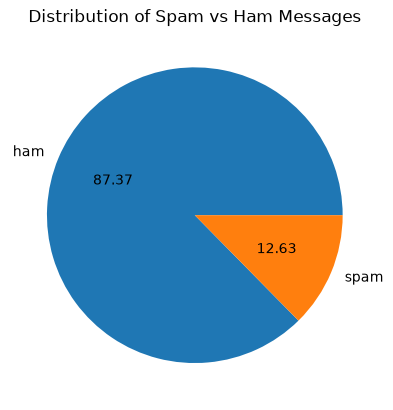

In [ ]:
## check for total ham and spam vaues and plot a graph
counts=df['target'].value_counts()
plt.pie(counts,labels=['ham','spam'],autopct='%0.2f')
plt.title('Distribution of Spam vs Ham Messages')
plt.show()

### NLTK Downloads for Text Processing
To perform natural language processing tasks such as tokenization, the Natural Language Toolkit (NLTK) library requires specific data packages. The `punkt` tokenizer model is downloaded for word and sentence tokenization, and `punkt_tab` is also downloaded, though `punkt` is typically sufficient for these tasks.

In [ ]:
nk.download('punkt')
nk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\SK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Feature Engineering: Message Lengths
New features are engineered from the `email_text` to capture characteristics that might differentiate spam from ham messages. The length of messages is often a discriminative feature:

*   **`email_text_words_len`**: This column stores the number of words in each email. `nltk.word_tokenize(x)` breaks the text into words, and `len()` counts them. Spam messages often exhibit different word counts compared to ham messages.

In [ ]:
## tokanize each email into words and save the count in new column
df['email_text_words_len']=df['email_text'].apply(lambda x:len(nk.word_tokenize(x)))

In [ ]:
df.head()

,target,email_text,email_text_char_lenght,email_text_words_len
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives around here though",61,15


### Feature Engineering: Sentence Lengths
*   **`email_text_sentence_len`**: This column stores the number of sentences in each email. `nltk.sent_tokenize(x)` breaks the text into sentences, and `len()` counts them. Similar to word length, sentence count can provide insights into message structure, which may vary between spam and legitimate messages.

In [ ]:
## Snetence tokanization
df['email_text_sentence_len']=df['email_text'].apply(lambda x:len(nk.sent_tokenize(x)))

df.head(5)

,target,email_text,email_text_char_lenght,email_text_words_len,email_text_sentence_len
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives around here though",61,15,1


## 3 Data Preprocessing
Text preprocessing is a crucial step to clean and normalize textual data before it can be effectively used by machine learning models. This process converts raw text into a standardized format, reducing noise and improving feature extraction. The following steps are applied:

1.  **Lowercasing**: Converts all text to lowercase to ensure that words like "Free" and "free" are treated as the same token.
2.  **Removing Special Characters**: Eliminates punctuation, numbers, and other non-alphabetic characters. This helps focus on the linguistic content of the text.
3.  **Tokenization**: Breaks down text into individual words or tokens. This is a foundational step for most NLP tasks.
4.  **Stop Word Removal**: Removes common words (e.g., "the", "a", "is") that carry little semantic meaning and do not contribute significantly to classification. This reduces dimensionality and noise.
5.  **Stemming**: Reduces words to their base or root form (e.g., "running", "ran" to "run"). This helps in treating different forms of a word as a single feature, reducing vocabulary size and improving generalization.

### Text Transformation Function (`transform_text`)
This Python function encapsulates the entire text preprocessing pipeline. It takes a raw text string as input and performs the following operations:

*   **Lowercase Conversion**: `text = text.lower()` converts the input text to lowercase.
*   **Special Character Removal**: `re.sub(r'[^a-zA-Z\s]', '', text)` uses regular expressions to remove any character that is not an alphabet letter or a whitespace. This cleans the text from numbers and punctuation.
*   **Tokenization**: `tokens = nltk.word_tokenize(text)` splits the cleaned text into individual words (tokens) using NLTK's word tokenizer.
*   **Stop Word Filtering**: `tokens = [token for token in tokens if token not in stop_words]` filters out common English stop words. The `stop_words` set is pre-loaded for efficient lookup.
*   **Stemming**: `stemmer = PorterStemmer()` initializes a Porter Stemmer, and `stemmed_tokens = [stemmer.stem(token) for token in tokens]` applies stemming to each token, reducing words to their root form.
*   **Joining Tokens**: Finally, `' '.join(stemmed_tokens)` reconstructs the processed text by joining the stemmed tokens back into a single string, separated by spaces.

In [ ]:
import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))  # loaded once, lowercase, set for O(1) lookup

def transform_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [token for token in tokens if token not in stop_words]
    stemmer = PorterStemmer()
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    return ' '.join(stemmed_tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Applying Text Transformation
The `transform_text` function is applied to the `email_text` column of the DataFrame. The result, which is the preprocessed version of each email, is stored in a new column named `transformed_text`. This column will serve as the input for feature extraction and model training.

In [ ]:
df['transformed_text'] = df['email_text'].apply(transform_text)

### Verification of Transformed Text
To ensure that the text transformation function works as expected, a sample row (index 2) is selected, and both the original `email_text` and the newly created `transformed_text` are displayed. This allows for a direct comparison and verification of the preprocessing steps (lowercasing, removal of special characters, stop words, and stemming).

In [ ]:
pd.set_option('display.max_colwidth', None)
df.loc[2,['email_text','transformed_text']]



email_text          Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
transformed_text                            free entri 2 wkli comp win fa cup final tkt 21st may 2005 text fa 87121 receiv entri questionstd txt ratetc appli 08452810075over18
Name: 2, dtype: str

### WordCloud

### Word Clouds for Visualizing Frequent Words
Word Clouds are graphical representations of word frequency, where the size of each word indicates its importance or frequency in a given text corpus. They provide a quick visual summary of the most prominent terms.

*   **Spam Word Cloud**: This Word Cloud is generated from the `transformed_text` of messages classified as spam (`target == 1`). It highlights the most frequent words found in spam messages, offering insights into common spam characteristics (e.g., promotional terms, urgent calls to action).
*   **Ham Word Cloud**: This Word Cloud is generated from the `transformed_text` of messages classified as ham (`target == 0`). It visualizes the most frequent words in legitimate messages, providing a contrast to spam and revealing typical conversational language patterns.

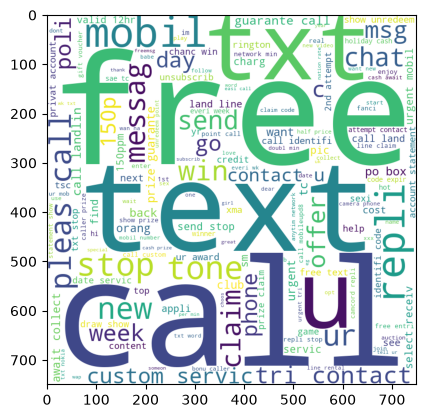

In [ ]:
from wordcloud import WordCloud
wc=WordCloud(width=750,height=750,background_color='white',min_font_size=10)

spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=' '))
plt.imshow(spam_wc)

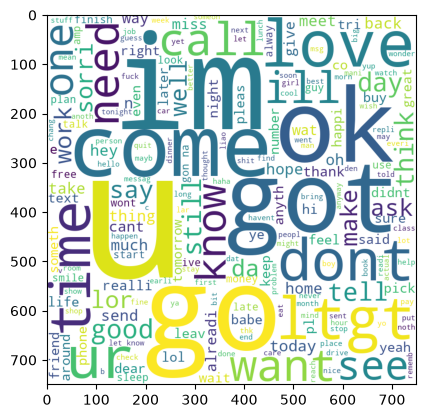

In [ ]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=' '))
plt.imshow(ham_wc)

#### Top 50 words in Spam

#### Top 50 Words in Spam Messages

### Extracting Most Common Words in Spam
To quantitatively identify the most frequent words in spam messages, all `transformed_text` from spam messages (`target == 1`) are concatenated into a single list called `spam_corpus`. Each word from the preprocessed text is appended to this list. This corpus will then be used to count word occurrences.

In [ ]:
spam_corpus=[]
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

The `len(spam_corpus)` command calculates the total number of words in the combined spam corpus after preprocessing. This provides a sense of the sheer volume of textual data derived from spam messages, indicating the scale of words available for frequency analysis.

In [ ]:
len(spam_corpus) ##total words in spam messages

10813

### Visualizing Top 50 Most Common Words in Spam
Using `collections.Counter`, the 50 most common words in the `spam_corpus` are identified. A bar chart is then generated to visualize these words and their frequencies. The `df_top` DataFrame facilitates the plotting process. This visualization provides a clear ranking of words that are most indicative of spam messages, reinforcing the insights gained from the Word Cloud and helping to understand the linguistic patterns of unwanted communications.

The chart's title has been updated to reflect the `top_words` count more accurately, displaying 'Top 50 Most Common Words in Spam Messages' to match the `most_common(50)` logic.

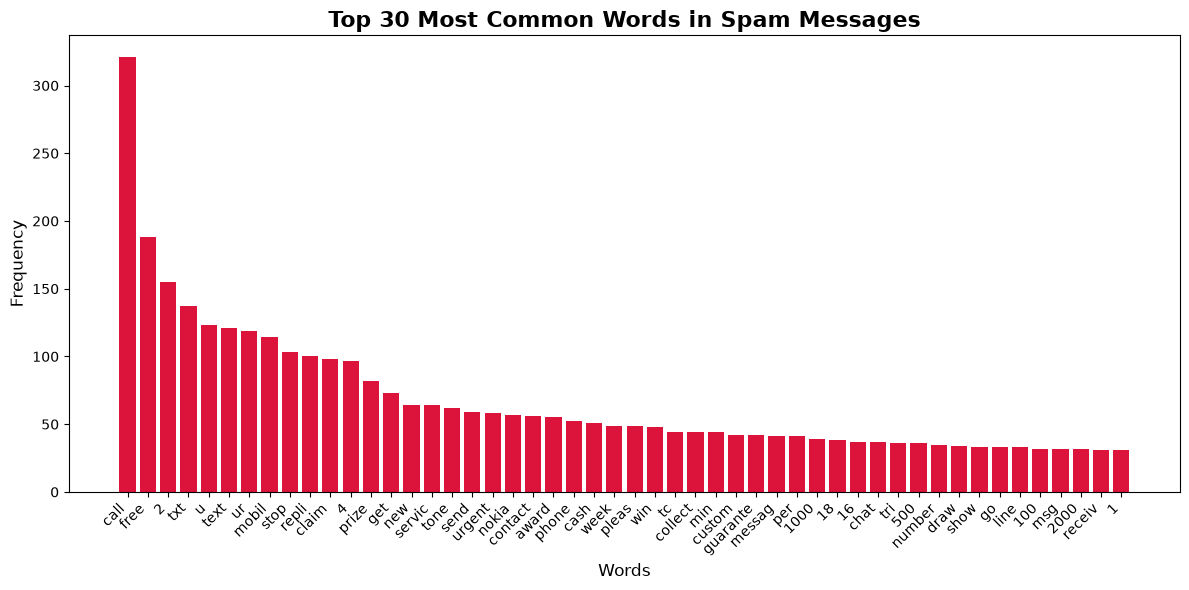

In [ ]:
## plot in bar hart for most commont words
from collections import Counter
top_words = Counter(spam_corpus).most_common(50)

df_top = pd.DataFrame(top_words, columns=['Word', 'Count'])
plt.figure(figsize=(12, 6))
plt.bar(df_top['Word'], df_top['Count'], color='crimson')

plt.title('Top 30 Most Common Words in Spam Messages', fontsize=16, fontweight='bold')
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Top 50 Words in Ham Messages

### Extracting Most Common Words in Ham
Similar to the spam message analysis, all `transformed_text` from ham messages (`target == 0`) are concatenated into a single list called `ham_corpus`. This corpus is used to collect all individual words from legitimate messages, enabling frequency analysis to understand common vocabulary in non-spam communications.

In [ ]:
ham_corpus=[]
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

The `len(ham_corpus)` command calculates the total number of words in the combined ham corpus after preprocessing. This metric gives an indication of the total linguistic content present in legitimate messages within the dataset, providing a basis for frequency comparisons.

In [ ]:
len(ham_corpus)

36813

### Visualizing Top 50 Most Common Words in Ham
Similar to the spam analysis, the 50 most common words in the `ham_corpus` are identified using `collections.Counter` and visualized through a bar chart. This plot highlights words frequently used in legitimate SMS messages. Comparing these top words with those found in spam messages can reveal distinct vocabulary patterns, which are crucial for effective spam detection.

The chart's title has been updated to 'Top 50 Most Common Words in Ham Messages' for accuracy, aligning with the `most_common(50)` selection criteria.

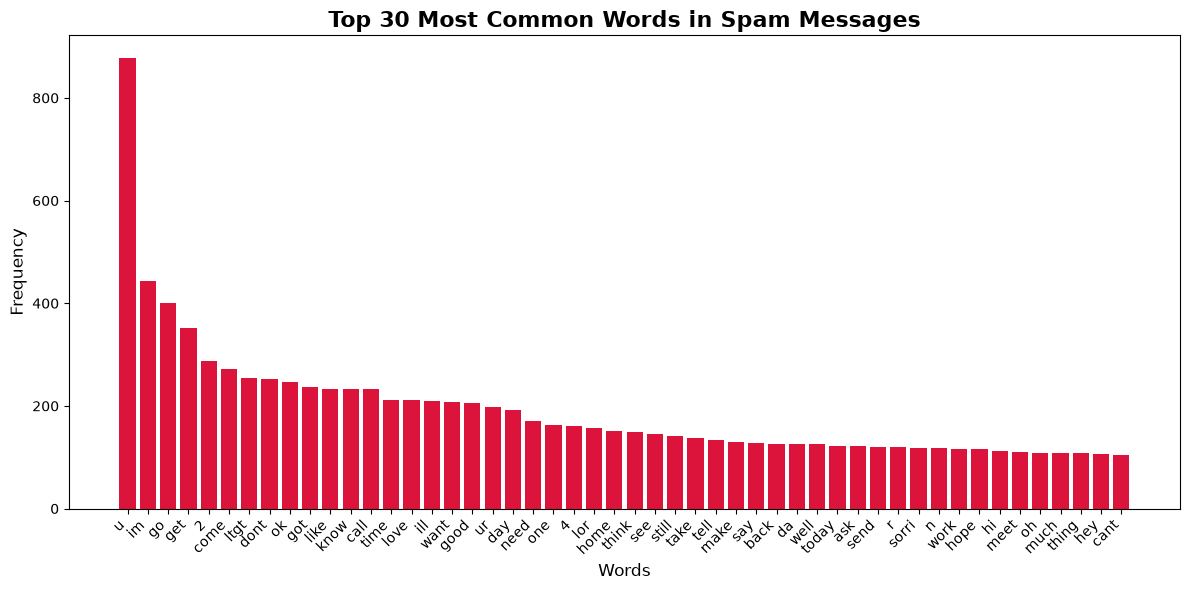

In [ ]:
## plot in bar hart for most commont words
from collections import Counter
top_words = Counter(ham_corpus).most_common(50)

df_top = pd.DataFrame(top_words, columns=['Word', 'Count'])
plt.figure(figsize=(12, 6))
plt.bar(df_top['Word'], df_top['Count'], color='crimson')

plt.title('Top 30 Most Common Words in Spam Messages', fontsize=16, fontweight='bold')
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Feature Extraction: TF-IDF

Feature extraction is the process of converting raw text data into numerical features that machine learning models can understand. For text classification, a common technique is Term Frequency-Inverse Document Frequency (TF-IDF).

**TF-IDF** is a numerical statistic that reflects how important a word is to a document in a collection or corpus. It is composed of two parts:
*   **Term Frequency (TF)**: Measures how frequently a term appears in a document. A higher TF means the word is more relevant to that document.
*   **Inverse Document Frequency (IDF)**: Measures how important a term is across the entire corpus. Words that appear frequently in many documents (like 'the' or 'a') will have a low IDF score, thus reducing their weight, while rare words will have a higher IDF score.

Combined, TF-IDF gives higher weight to words that are frequent in a specific document but rare across the entire corpus, effectively highlighting important distinguishing terms.

### Train-Test Split
The dataset is divided into training and testing sets to evaluate the model's performance on unseen data. `train_test_split` from `sklearn.model_selection` is used with the following parameters:
*   `X`: The input features, which is the `transformed_text` column.
*   `y`: The target variable, which is the `target` column.
*   `test_size=0.2`: 20% of the data is allocated for the test set.
*   `random_state=42`: Ensures reproducibility of the split.

### TF-IDF Vectorization

`TfidfVectorizer` is initialized and applied to transform the `transformed_text` into numerical TF-IDF features:

*   `max_features=3000`: This parameter limits the number of features (words) to the 3000 most frequent ones. This helps reduce dimensionality and computational complexity.
*   `ngram_range=(1, 2)`: This indicates that the vectorizer will consider both unigrams (single words) and bigrams (sequences of two words) as features. N-grams can capture more contextual information than single words alone.

*   `tfidf.fit_transform(X_train)`: The vectorizer learns the vocabulary and IDF weights from the training data (`X_train`) and transforms it into a TF-IDF matrix (`X_train_tfidf`).
*   `tfidf.transform(X_test)`: The test data (`X_test`) is transformed using the vocabulary and IDF weights learned from the training data. It is crucial to only `transform` the test set and not `fit_transform` it, to prevent data leakage from the test set into the training process.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df['transformed_text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## Model Training

##### we will try two models for taraining to see which one performs better Naive Bayes and ExtraTreesClassifier

##### Model Selection and Training

This section trains and evaluates multiple classification models to determine their effectiveness in distinguishing between spam and ham messages. The goal is to identify a model that performs optimally given the characteristics of the dataset.

Three distinct classification algorithms are selected for comparison:

*   **Multinomial Naive Bayes (`MultinomialNB`)**: A probabilistic classifier based on Bayes' theorem, particularly well-suited for text classification with discrete features (like word counts or TF-IDF scores). It assumes feature independence, which simplifies computation.
*   **Extra Trees Classifier (`ExtraTreesClassifier`)**: An ensemble learning method that builds multiple randomized decision trees and aggregates their predictions. It's known for its ability to handle high-dimensional data and reduce overfitting.
*   **Logistic Regression (`LogisticRegression`)**: A linear model used for binary classification. Despite its name, it's a classification algorithm that models the probability of a binary outcome. It's robust, interpretable, and a good baseline for many classification tasks.

Each model is trained on the `X_train_tfidf` (TF-IDF transformed training data) and `y_train` (encoded target labels). After training, predictions are made on the `X_test_tfidf` and `y_test` to evaluate performance using standard classification metrics.

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Naive Bayes': MultinomialNB(),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'lr' : LogisticRegression(max_iter=1000)
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    print(f"\n{name}")
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"  F1 Score  : {f1_score(y_test, y_pred):.4f}")


Naive Bayes
  Accuracy  : 0.9739
  Precision : 1.0000
  Recall    : 0.8138
  F1 Score  : 0.8973

Extra Trees
  Accuracy  : 0.9758
  Precision : 0.9839
  Recall    : 0.8414
  F1 Score  : 0.9071

lr
  Accuracy  : 0.9642
  Precision : 0.9576
  Recall    : 0.7793
  F1 Score  : 0.8593


### Model Performance Metrics

After training, each model's performance on the test set is evaluated using several key metrics. These metrics provide a comprehensive understanding of how well each model classifies spam and ham messages:

*   **Accuracy**: The proportion of correctly classified instances out of the total instances. While a general measure, it can be misleading in imbalanced datasets.
*   **Precision**: The proportion of true positive predictions among all positive predictions. In the context of spam, it measures the model's ability to correctly identify spam without flagging too many legitimate messages as spam (minimizing false positives).
*   **Recall**: The proportion of true positive predictions among all actual positive instances. For spam detection, it measures the model's ability to identify all actual spam messages (minimizing false negatives).
*   **F1 Score**: The harmonic mean of precision and recall. It provides a balanced measure of the model's performance, especially useful in imbalanced datasets where both false positives and false negatives are important.

The output shows the performance of each model. Naive Bayes and Extra Trees classifiers demonstrate strong performance, with Naive Bayes achieving a perfect precision score (1.0000), indicating no ham messages were incorrectly classified as spam by this model in the test set.

##### Naive bayes is better as it puts no ham message in spam 100%

##### Model Selection: Naive Bayes

Based on the evaluation metrics, the Naive Bayes model (specifically Multinomial Naive Bayes) is selected as the preferred model for this spam classification task. The primary reason for this selection is its precision score of 1.0000. This indicates that the Naive Bayes model did not incorrectly classify any legitimate ('ham') messages as 'spam' in the test set. While its recall and F1-score are slightly lower than Extra Trees, the perfect precision is highly desirable in spam filtering applications, where minimizing false positives (ham classified as spam) is often a top priority to avoid disrupting user communication.

## Model Evaluation

### 1. Confusion Matrix

A Confusion Matrix is a table used to describe the performance of a classification model on a set of test data for which the true values are known. It allows for the visualization of the performance of an algorithm. For a binary classification problem (like spam vs. ham), it typically has four outcomes:

*   **True Positives (TP)**: Correctly predicted positive values (e.g., actual spam correctly identified as spam).
*   **True Negatives (TN)**: Correctly predicted negative values (e.g., actual ham correctly identified as ham).
*   **False Positives (FP)**: Incorrectly predicted positive values (e.g., actual ham incorrectly identified as spam – Type I error).
*   **False Negatives (FN)**: Incorrectly predicted negative values (e.g., actual spam incorrectly identified as ham – Type II error).

In this context, the Confusion Matrix for the Naive Bayes model (selected as the best performing model) is generated. The `ConfusionMatrixDisplay` function from `sklearn.metrics` is used to visualize the matrix, providing a clear breakdown of the model's classification accuracy across both classes. The `display_labels` are set to 'Ham' and 'Spam' for better interpretability.

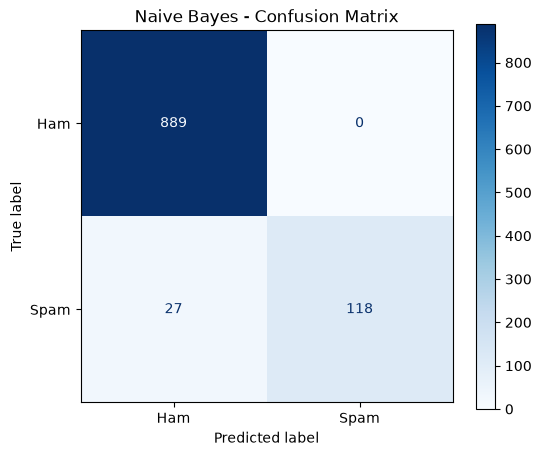

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
nb = models['Naive Bayes']

y_pred = nb.predict(X_test_tfidf)
y_prob = nb.predict_proba(X_test_tfidf)[:, 1]

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Naive Bayes - Confusion Matrix')
plt.show()

### 2. ROC Curve and AUC Score

The Receiver Operating Characteristic (ROC) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings.

*   **True Positive Rate (TPR)**: Also known as Sensitivity or Recall, it's the proportion of actual positives that are correctly identified as such.
*   **False Positive Rate (FPR)**: The proportion of actual negatives that are incorrectly classified as positive.

The **Area Under the Curve (AUC)** measures the entire two-dimensional area underneath the entire ROC curve. AUC provides an aggregate measure of performance across all possible classification thresholds. An AUC of 1.0 represents a perfect classifier, while an AUC of 0.5 represents a random classifier (equivalent to flipping a coin).

For the Naive Bayes model, the ROC curve is plotted, and the AUC score is calculated. This visualization and score provide an understanding of the model's ability to distinguish between the two classes across different thresholds, indicating its overall discriminative power.

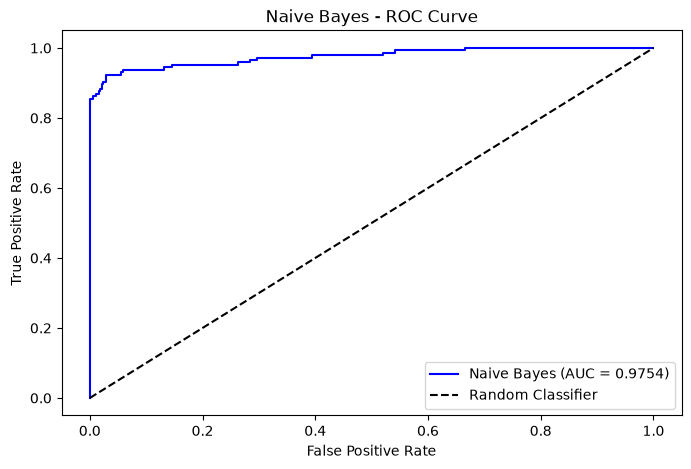

AUC Score: 0.9754


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, ConfusionMatrixDisplay


fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'Naive Bayes (AUC = {auc:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Naive Bayes - ROC Curve')
plt.legend()
plt.show()

print(f"AUC Score: {auc:.4f}")

#### Results

#### Summary of Naive Bayes Model Performance

This section provides a detailed breakdown of the Naive Bayes model's performance on the test set, derived from the confusion matrix:

*   **True Positives (TP)**: 118 (Spam messages correctly identified as spam)
*   **True Negatives (TN)**: 889 (Ham messages correctly identified as ham)
*   **False Positives (FP)**: 0 (Ham messages incorrectly identified as spam)
*   **False Negatives (FN)**: 27 (Spam messages incorrectly identified as ham)

Based on these values, the following key metrics are calculated:

*   **Precision**: `TP / (TP + FP) = 118 / (118 + 0) = 1.0000`
    *   A perfect precision score indicates that out of all messages predicted as spam, none were actually ham. This is highly desirable for minimizing false alarms in spam detection.

*   **Recall**: `TP / (TP + FN) = 118 / (118 + 27) = 0.8138`
    *   The recall score indicates that the model identified approximately 81.38% of all actual spam messages. This means 27 spam messages were missed (false negatives).

*   **Accuracy**: `(TP + TN) / Total = (118 + 889) / (889 + 0 + 27 + 118) = 1007 / 1034 = 0.9739`
    *   The overall accuracy of the model is approximately 97.39%, meaning a high proportion of messages were correctly classified. However, due to class imbalance, precision and recall provide a more nuanced view of performance.